# 04 — Rule-Based Exception Testing

**What this notebook establishes:** the deterministic red-flag rules applied to every transaction, their individual flag rates, and the population-level control tests (e.g. off-hours trading) that justify each rule's threshold.

**Estimated runtime:** ~1 minute

All logic lives in `src/`; this notebook only calls into it and displays results (plan/00_MASTER_PLAN.md sec 5).

## 1. The rules

`src/rules.py` (Stage 5) applies ten deterministic exception tests: `DUPLICATE_INVOICE`, `SPLIT_AMOUNT`, `LARGE_AMOUNT`, `ROUND_NUMBER`, `ROUND_DOLLARS`, `HIGH_QUANTITY`, `ODD_QUANTITY`, `OFF_HOUR`, `NEGATIVE_ADJUSTMENT`, `ZERO_QUANTITY` — each maps to a specific audit rationale (e.g. `SPLIT_AMOUNT` -> structuring below an authorisation limit).

In [1]:
import json
import pandas as pd
from pathlib import Path
ROOT = Path('..').resolve()
summary = json.loads((ROOT/'reports/metrics/rule_summary.json').read_text())
print('flagged:', summary['n_flagged'], '/', summary['total_rows'], f"({summary['flagged_pct']}%)")
pd.Series(summary['rule_counts']).sort_values(ascending=False)

flagged: 194792 / 1030804 (18.9%)


ROUND_NUMBER           113491
SPLIT_AMOUNT            68925
ROUND_DOLLARS           28106
DUPLICATE_INVOICE       22443
LARGE_AMOUNT            10300
HIGH_QUANTITY            9979
NEGATIVE_ADJUSTMENT         5
ZERO_QUANTITY               0
ODD_QUANTITY                0
OFF_HOUR                    0
dtype: int64

## 2. Overlap

How many rules fire on the same row (more overlap = higher-confidence flag):

In [2]:
pd.Series(summary['overlap_stats'])

exactly_1    145829
exactly_2     40413
exactly_3      7662
4_or_more       888
dtype: int64

## 3. The off-hours control test

`plan/00_MASTER_PLAN.md` sec 2.7 requires the hour-of-day histogram to be inspected empirically before trusting an off-hours flag — this dataset trades nearly nothing overnight, so the flag is meaningful here (unlike many retail datasets with no usable time component).

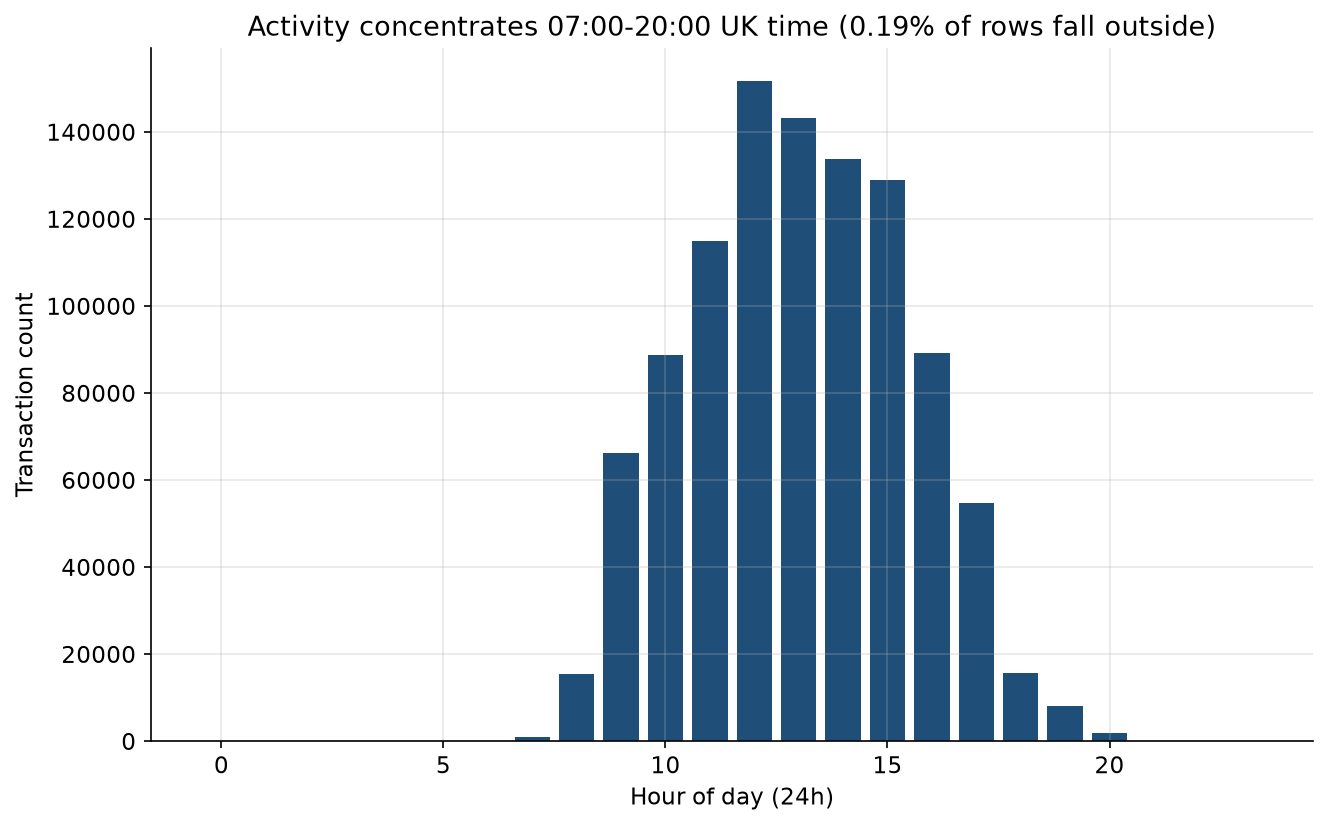

In [3]:
from IPython.display import Image
Image(filename=str(ROOT/'reports/figures/hour_distribution.png'))

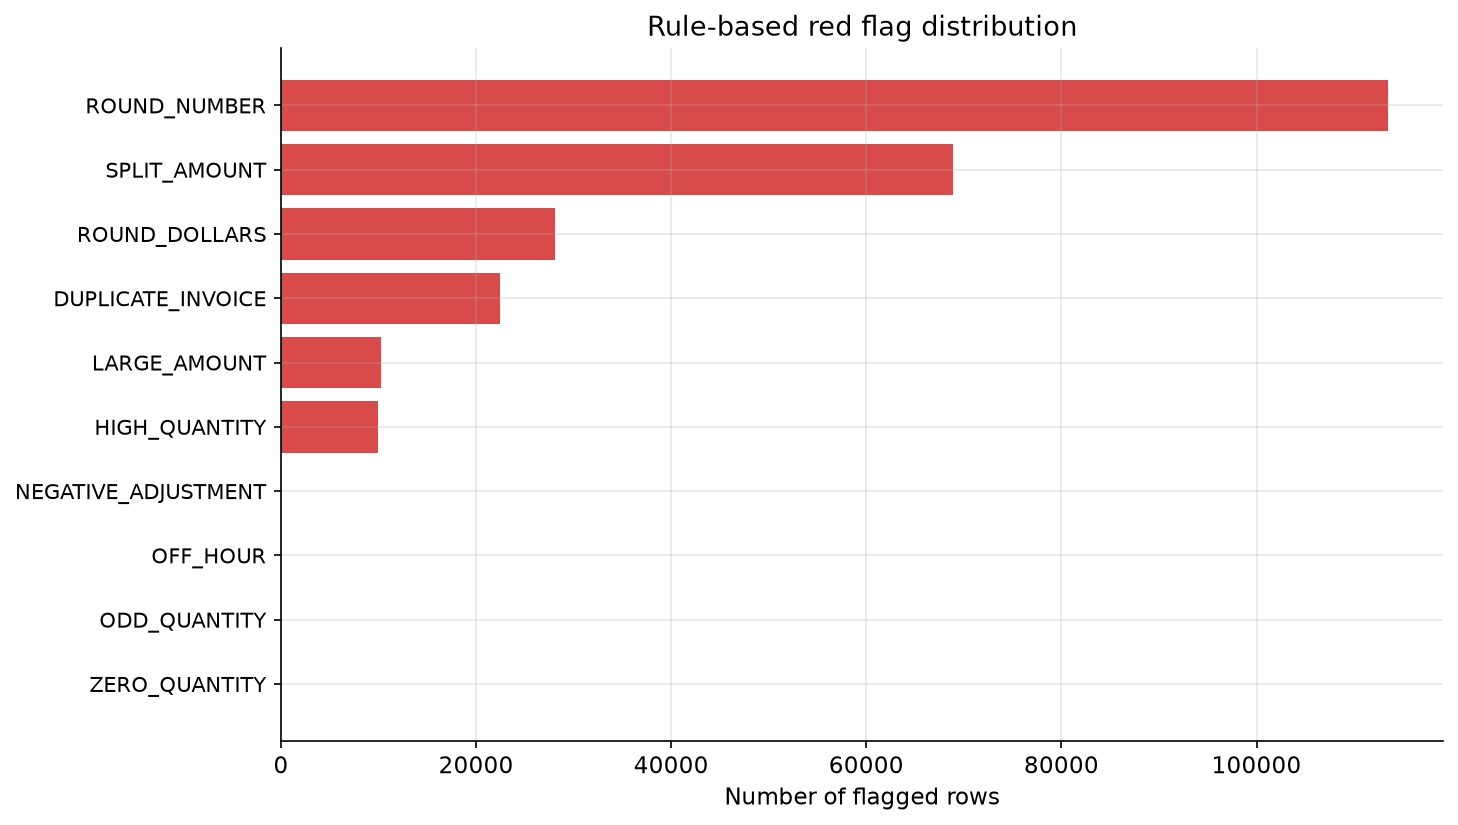

In [4]:
Image(filename=str(ROOT/'reports/figures/rule_distribution.png'))

## 4. Rule activity over time

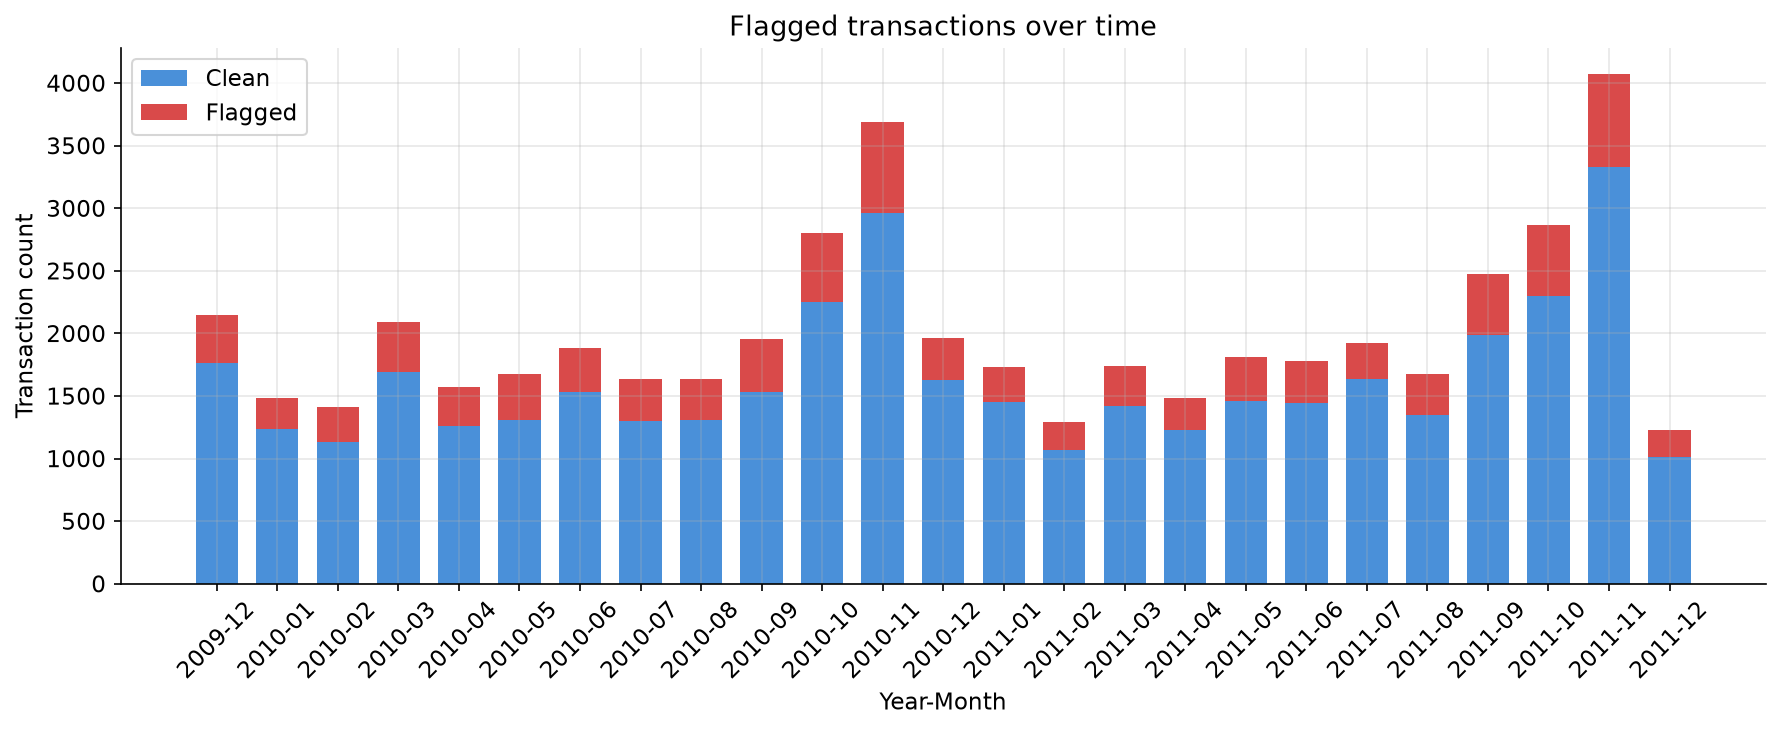

In [5]:
Image(filename=str(ROOT/'reports/figures/rule_time_series.png'))